### Vector Embedding 

In [1]:
from openai import OpenAI
from dotenv import load_dotenv, find_dotenv
import os

_ = load_dotenv(find_dotenv(), override=True)

API_HOST = os.getenv("API_HOST", "azure")
print(API_HOST)

openai


In [2]:
if API_HOST == "openai":
    client = OpenAI(api_key=os.getenv("OPENAI_KEY"))

In [3]:
print(client)

In [4]:
model = os.getenv("OPENAI_EMBEDDING_MODEL")
print(model)

text-embedding-3-small


In [5]:
texts = [
    "I love football",
    "I enjoy soccer",
    "The sky is blue"
]

response = client.embeddings.create(
    model=model,
    input=texts,
    dimensions=1536
)

print(response)

CreateEmbeddingResponse(data=[Embedding(embedding=[0.002498626708984375, 0.007038116455078125, -0.050933837890625, 0.0036830902099609375, 0.0021514892578125, -0.038787841796875, 0.04193115234375, 0.01392364501953125, -0.032012939453125, 0.0082855224609375, -0.0221710205078125, 0.0018720626831054688, -0.043914794921875, 0.0218048095703125, 0.0164031982421875, -0.0164947509765625, -0.057830810546875, -0.00875091552734375, 0.05169677734375, -0.0156402587890625, 0.02728271484375, 0.0297393798828125, -0.0011034011840820312, -0.037017822265625, -0.00975799560546875, 0.028900146484375, 0.0301666259765625, 0.0236663818359375, -0.0313720703125, 0.01029205322265625, 0.051177978515625, -0.0263519287109375, 0.00406646728515625, -0.0252838134765625, 0.023345947265625, -0.0190277099609375, 0.0032825469970703125, 0.0009088516235351562, 0.0267333984375, 0.033203125, 0.054595947265625, 0.0227508544921875, 0.0267181396484375, -0.03765869140625, 0.00400543212890625, -0.004726409912109375, -0.034240722656

In [6]:
response.data[0].embedding

[0.002498626708984375,
 0.007038116455078125,
 -0.050933837890625,
 0.0036830902099609375,
 0.0021514892578125,
 -0.038787841796875,
 0.04193115234375,
 0.01392364501953125,
 -0.032012939453125,
 0.0082855224609375,
 -0.0221710205078125,
 0.0018720626831054688,
 -0.043914794921875,
 0.0218048095703125,
 0.0164031982421875,
 -0.0164947509765625,
 -0.057830810546875,
 -0.00875091552734375,
 0.05169677734375,
 -0.0156402587890625,
 0.02728271484375,
 0.0297393798828125,
 -0.0011034011840820312,
 -0.037017822265625,
 -0.00975799560546875,
 0.028900146484375,
 0.0301666259765625,
 0.0236663818359375,
 -0.0313720703125,
 0.01029205322265625,
 0.051177978515625,
 -0.0263519287109375,
 0.00406646728515625,
 -0.0252838134765625,
 0.023345947265625,
 -0.0190277099609375,
 0.0032825469970703125,
 0.0009088516235351562,
 0.0267333984375,
 0.033203125,
 0.054595947265625,
 0.0227508544921875,
 0.0267181396484375,
 -0.03765869140625,
 0.00400543212890625,
 -0.004726409912109375,
 -0.03424072265625,


In [7]:
len(response.data[0].embedding)

1536

In [8]:
import numpy as np 


np.array(response.data[0].embedding).shape

(1536,)

In [9]:
from openai import OpenAI
import numpy as np
import os

client = OpenAI(api_key=os.getenv("OPENAI_KEY"))

texts = [
    "I love football",
    "I enjoy soccer",
    "The sky is blue"
]

response = client.embeddings.create(
    model="text-embedding-3-small",
    input=texts
)

embeddings = [item.embedding for item in response.data]

print(len(embeddings[0]))  # dimension size

1536


In [10]:
print(len(embeddings[1]))

1536


In [11]:
print(len(embeddings[2]))

1536


In [12]:
def cosine_similarity(a, b):
    a = np.array(a)
    b = np.array(b)
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

print(cosine_similarity(embeddings[0], embeddings[1]))  # similar
print(cosine_similarity(embeddings[0], embeddings[2]))  # not similar

0.6255862499501322
0.19515065783522997


In [13]:
def cosine_similarity(a, b):
    a = np.array(a)
    b = np.array(b)
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)) > 0.5

print(cosine_similarity(embeddings[0], embeddings[1]))  # similar
print(cosine_similarity(embeddings[0], embeddings[2]))  # not similar

True
False


In [14]:
def cosine_similarity(a, b):
    a = np.array(a)
    b = np.array(b)
    similarity = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)) 
    if similarity > 0.5:
        return "Similar"
    else:
        return "Not Similar"

print(cosine_similarity(embeddings[0], embeddings[1]))  # similar
print(cosine_similarity(embeddings[0], embeddings[2]))  # not similar

Similar
Not Similar


In [15]:
def cosine_similarity(a, b):
    a = np.array(a)
    b = np.array(b)
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

In [16]:
query = "soccer game"

query_embedding = client.embeddings.create(
    model="text-embedding-3-small",
    input=query
).data[0].embedding

scores = []

for i, emb in enumerate(embeddings):
    score = cosine_similarity(query_embedding, emb)
    scores.append((texts[i], score))

# sort by similarity
results = sorted(scores, key=lambda x: x[1], reverse=True)

for r in results:
    print(r)

('I enjoy soccer', np.float64(0.6012718278378151))
('I love football', np.float64(0.44472307509245657))
('The sky is blue', np.float64(0.18026292100477206))


In [17]:
import numpy as np

texts = [
    "I love football",
    "Soccer is amazing",
    "Messi is the best player",
    "I enjoy cooking food",
    "Recipes are fun",
    "The kitchen is clean"
]

response = client.embeddings.create(
    model="text-embedding-3-small",
    input=texts
)

embeddings = np.array([item.embedding for item in response.data])

In [18]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=2, random_state=42)
reduced_embeddings = tsne.fit_transform(embeddings)

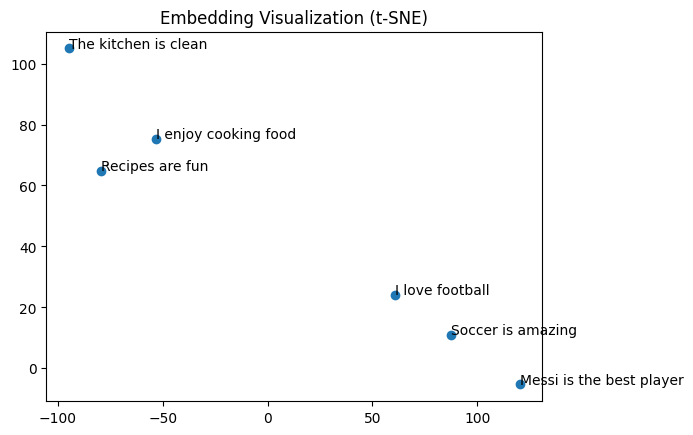

In [19]:
import matplotlib.pyplot as plt

x = reduced_embeddings[:, 0]
y = reduced_embeddings[:, 1]

plt.figure()
plt.scatter(x, y)

# Add labels
for i, text in enumerate(texts):
    plt.text(x[i], y[i], text)

plt.title("Embedding Visualization (t-SNE)")
plt.show()

In [22]:
# Load in vector embeddings for 1000 most common words
import json
    
with open('vector-embeddings-demos/embeddings/words_text-embedding-ada-002.json') as f:
    vectors_ada2 = json.load(f)

with open('vector-embeddings-demos/embeddings/words_text-embedding-3-small-1536.json') as f:
    vectors_emb3 = json.load(f)

with open('vector-embeddings-demos/embeddings/words_word2vec-google-news.json') as f:
    vectors_word2vec = json.load(f)

In [23]:
vectors_ada2['dog']

[-0.0034173328895121813,
 -0.01776607520878315,
 -0.015954313799738884,
 -0.017401019111275673,
 -0.018022965639829636,
 0.021957462653517723,
 -0.012411915697157383,
 -0.022795740514993668,
 -0.021254390478134155,
 -0.01815817318856716,
 0.012364593334496021,
 0.0387500524520874,
 0.0015590947587043047,
 -0.00697663240134716,
 -0.013736934401094913,
 0.02422892488539219,
 0.039993949234485626,
 0.001188123133033514,
 0.00951850600540638,
 -0.012134742923080921,
 -0.019875289872288704,
 0.00605385098606348,
 0.01127618458122015,
 -0.02514832466840744,
 -0.007632381282746792,
 0.010356783866882324,
 0.009809198789298534,
 -0.008470659144222736,
 -0.005692174658179283,
 -0.00943062175065279,
 0.007422812283039093,
 -0.00914668943732977,
 -0.025229448452591896,
 -0.0211732666939497,
 -0.005911884363740683,
 -0.018942367285490036,
 -0.007571538910269737,
 -0.01608951948583126,
 -0.011681802570819855,
 -0.020916376262903214,
 0.004505741409957409,
 0.011026053689420223,
 0.01156687736511230

In [24]:
def cosine_similarity(v1, v2):

  dot_product = sum(
    [a * b for a, b in zip(v1, v2)])
  
  magnitude = (
    sum([a**2 for a in v1]) *
    sum([a**2 for a in v2])) ** 0.5

  return dot_product / magnitude

In [25]:
cosine_similarity(vectors_emb3['dog'], vectors_emb3['cat'])

0.6025387572540721

In [26]:
my_dict = {"a": 3, "b": 7, "c": 1, "d": 0.5}

sorted(my_dict)

['a', 'b', 'c', 'd']

## Most similar words

We can find the most similar words to a given word using the cosine similarity metric.

In [31]:
import pandas as pd 
from typing import List, Dict

def most_similar(word: str, vectors: Dict[str, List]) -> pd.DataFrame:
    word_vector = vectors[word]
    similarities = {w: cosine_similarity(word_vector, vector) for w, vector in vectors.items()}
    sorted_similarities = sorted(similarities, key=similarities.get, reverse=True)
    print(sorted_similarities)
    return pd.DataFrame([(word, similarities[word]) for word in sorted_similarities[:10]], columns=["word", "similarity"])

In [32]:
word = 'dog'
most_similar(word, vectors_ada2)

['dog', 'animal', 'god', 'cat', 'fish', 'bird', 'diet', 'horse', 'drug', 'gun', 'lord', 'owner', 'dad', 'agent', 'child', 'food', 'daughter', 'baby', 'pair', 'deal', 'girl', 'job', 'behavior', 'doctor', 'bishop', 'smith', 'woman', 'chairman', 'house', 'vehicle', 'day', 'party', 'meal', 'bag', 'worker', 'victim', 'jack', 'bread', 'document', 'son', 'door', 'lot', 'firm', 'stuff', 'hole', 'player', 'mary', 'pain', 'mind', 'motor', 'bed', 'friend', 'machine', 'danger', 'bob', 'game', 'hand', 'road', 'wine', 'holiday', 'species', 'drive', 'peace', 'boat', 'defense', 'car', 'plant', 'pool', 'boy', 'lee', 'band', 'rock', 'grass', 'tour', 'crime', 'driver', 'paper', 'box', 'sex', 'spot', 'man', 'drink', 'parent', 'ship', 'fruit', 'christ', 'hotel', 'tree', 'patient', 'club', 'song', 'restaurant', 'damage', 'engine', 'room', 'john', 'law', 'park', 'staff', 'family', 'client', 'train', 'computer', 'hope', 'desk', 'school', 'teacher', 'user', 'aid', 'radio', 'trip', 'brown', 'candidate', 'manage

,word,similarity
0,dog,1.000000
1,animal,0.885472
2,god,0.865986
3,cat,0.863493
4,fish,0.856640
5,bird,0.855640
6,diet,0.852973
7,horse,0.852069
8,drug,0.850611
9,gun,0.849355


In [33]:
most_similar(word, vectors_emb3)

['dog', 'animal', 'horse', 'cat', 'boy', 'man', 'child', 'bird', 'door', 'baby', 'dad', 'doctor', 'hand', 'god', 'woman', 'girl', 'gun', 'car', 'kind', 'boat', 'foot', 'thing', 'daughter', 'adult', 'sport', 'bar', 'person', 'drug', 'object', 'vehicle', 'driver', 'eye', 'parent', 'bob', 'day', 'body', 'walk', 'ball', 'care', 'box', 'customer', 'player', 'food', 'owner', 'chest', 'bag', 'fish', 'target', 'lord', 'phone', 'cup', 'job', 'drive', 'species', 'danger', 'game', 'user', 'individual', 'row', 'consumer', 'love', 'deal', 'bus', 'favor', 'king', 'behavior', 'race', 'worker', 'agent', 'board', 'diet', 'motor', 'wife', 'desk', 'son', 'stuff', 'head', 'task', 'look', 'department', 'defense', 'piece', 'football', 'client', 'work', 'sector', 'victim', 'command', 'jack', 'rock', 'side', 'death', 'stone', 'role', 'figure', 'neck', 'wood', 'hole', 'order', 'chair', 'leg', 'field', 'world', 'band', 'guy', 'club', 'coffee', 'road', 'joe', 'decision', 'peter', 'mind', 'choice', 'occasion', 's

,word,similarity
0,dog,1.000000
1,animal,0.681331
2,horse,0.674941
3,cat,0.602539
4,boy,0.556805
5,man,0.531099
6,child,0.522607
7,bird,0.510155
8,door,0.480681
9,baby,0.473690


In [34]:
most_similar(word, vectors_word2vec)

['dog', 'cat', 'animal', 'horse', 'bird', 'child', 'baby', 'boy', 'woman', 'mother', 'girl', 'daughter', 'person', 'car', 'man', 'park', 'bag', 'tree', 'son', 'dad', 'gun', 'brown', 'husband', 'guy', 'vehicle', 'friend', 'pub', 'walk', 'house', 'food', 'nose', 'gentleman', 'van', 'sister', 'brother', 'grass', 'police', 'uncle', 'beach', 'wife', 'lady', 'adult', 'father', 'owner', 'meat', 'neck', 'mum', 'bottle', 'fish', 'drink', 'hair', 'garden', 'boat', 'family', 'victim', 'property', 'restaurant', 'street', 'bar', 'bath', 'breakfast', 'tom', 'train', 'leg', 'description', 'driver', 'heart', 'home', 'meal', 'drug', 'mouth', 'kind', 'kitchen', 'bedroom', 'bed', 'love', 'nature', 'lunch', 'behavior', 'door', 'bush', 'snow', 'body', 'care', 'plane', 'hell', 'exercise', 'fire', 'type', 'ball', 'race', 'john', 'fun', 'cup', 'milk', 'castle', 'search', 'diet', 'partner', 'item', 'reader', 'skin', 'attitude', 'character', 'motor', 'dinner', 'bread', 'ref', 'doctor', 'thing', 'way', 'spirit',

,word,similarity
0,dog,1.000000
1,cat,0.760946
2,animal,0.643801
3,horse,0.482581
4,bird,0.450441
5,child,0.370100
6,baby,0.356009
7,boy,0.352168
8,woman,0.351105
9,mother,0.345503


## Visualizations of similarity space

We can visualize the word vectors in 2D space using dimensionality reduction techniques like PCA (Principal Components Analysis). This allows us to see the relationships between words and how they cluster together. _Note that dimensionality reduction is a very lossy process!_

In [35]:
import numpy as np
from sklearn.decomposition import PCA


def perform_pca(vectors: dict):
    """Perform PCA on the word vectors and return the PCA-transformed vectors"""
    X = np.array(list(vectors.values()))
    pca = PCA(n_components=3)
    X_pca = pca.fit_transform(X)
    X_pca = {list(vectors.keys())[i]: X_pca[i] for i in range(len(vectors))}
    return X_pca

vectors_w2vc_pca = perform_pca(vectors_word2vec)
vectors_ada2_pca = perform_pca(vectors_ada2)
vectors_emb3_pca = perform_pca(vectors_emb3)

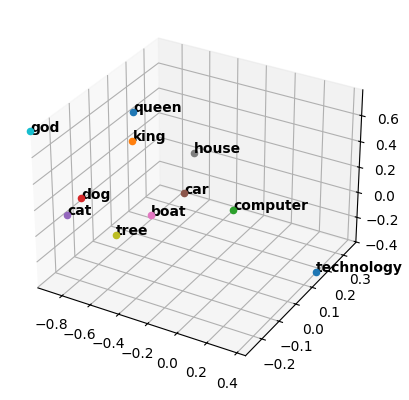

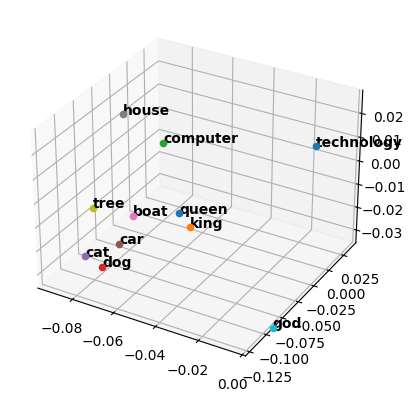

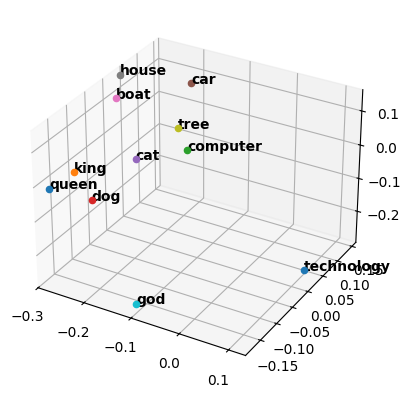

In [36]:
import matplotlib.pyplot as plt

def render_vectors_3d(vectors: dict, filename: str):
    """Render 3-dimensional vectors (key: [,,,]) in a 3D plot"""
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    fig.patch.set_alpha(0.0)
    # Plot the vectors as points
    for key, vector in vectors.items():
        ax.scatter(vector[0], vector[1], vector[2])
        ax.text(vector[0], vector[1], vector[2], key, fontweight="bold")

    # Figure out the max and min values for each dimension
    min_x = min(v[0] for v in vectors.values())
    max_x = max(v[0] for v in vectors.values())
    min_y = min(v[1] for v in vectors.values())
    max_y = max(v[1] for v in vectors.values())
    min_z = min(v[2] for v in vectors.values())
    max_z = max(v[2] for v in vectors.values())
    ax.set_xlim([min_x, max_x])
    ax.set_ylim([min_y, max_y])
    ax.set_zlim([min_z, max_z])
    plt.show()
    fig.savefig(filename, transparent=False, dpi=300, bbox_inches='tight')



# Get subset of the vectors for plotting
words = ['queen', 'king', 'computer', 'dog', 'cat', 'car', 'boat', 'house', 'tree', 'god', 'technology']

word_pca_vectors_w2vc = {word: vectors_w2vc_pca[word] for word in words}
word_pca_vectors_ada2 = {word: vectors_ada2_pca[word] for word in words}
word_pca_vectors_emb3 = {word: vectors_emb3_pca[word] for word in words}

# Plot the vectors
render_vectors_3d(word_pca_vectors_w2vc, 'pca_word2vec.png')
render_vectors_3d(word_pca_vectors_ada2, 'pca_ada002.png')
render_vectors_3d(word_pca_vectors_emb3, 'pca_emb3.png')

## Range of similarity values

Each embedding model has a different range of similarity values, so you should not assume that a similarity of 0.5 in one model is the same as a similarity of 0.5 in another model. Always check the range of similarity values for the model you are using.

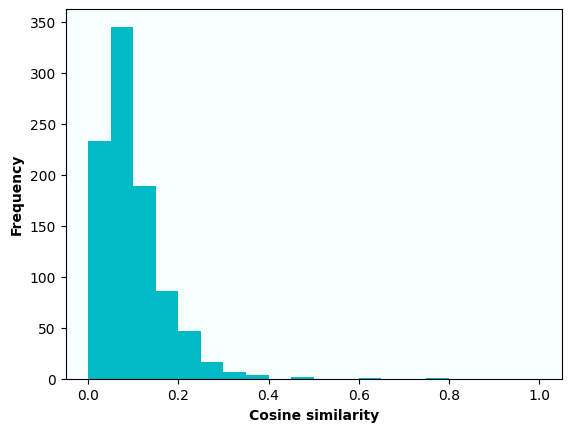

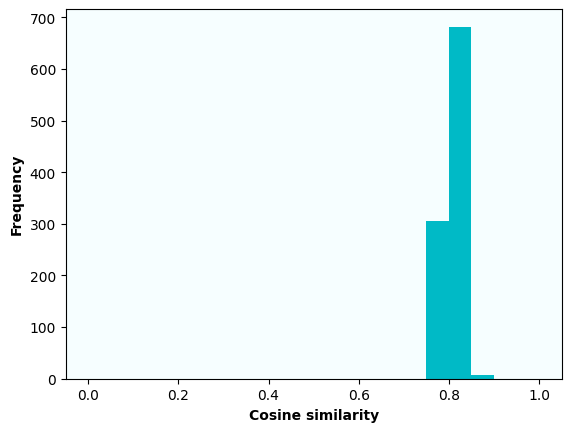

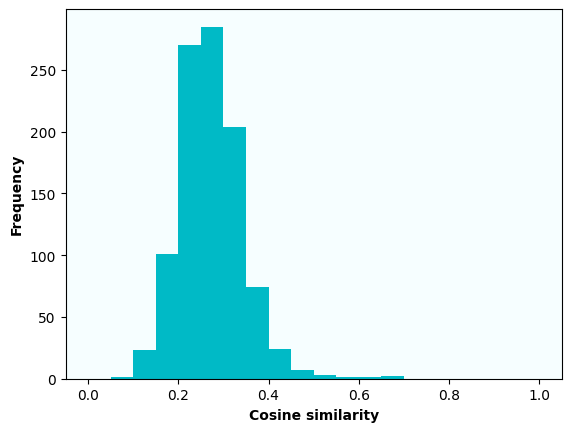

In [37]:
import matplotlib.pyplot as plt

def cosine_similarity_histogram(word: str, vectors: dict, filename):
    """Plot a histogram of the cosine similarities of the word to all other words"""
    word_vector = vectors[word]
    similarities = [cosine_similarity(word_vector, vectors[w]) for w in vectors if w != word]
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.set_facecolor('#f6feff')
    fig.patch.set_alpha(0.0)
    ax.hist(similarities, bins=20, range=(0, 1), color='#00bac6')
    ax.set_xlabel('Cosine similarity', fontweight='bold')
    ax.set_ylabel('Frequency', fontweight='bold')
    plt.show()
    fig.savefig(filename, transparent=False, dpi=300, bbox_inches='tight')


word = 'dog'
cosine_similarity_histogram(word, vectors_word2vec, "similarity_word2vec.png")
cosine_similarity_histogram(word, vectors_ada2, "similarity_ada002.png")
cosine_similarity_histogram(word, vectors_emb3, "similarity_emb3.png")


In [38]:
import json

with open('vector-embeddings-demos/embeddings/movies_text-embedding-3-small-1536.json') as f:
    movies = json.load(f)

In [40]:
type(movies)

dict

In [42]:
movies.keys()

dict_keys(['Snow White and the Seven Dwarfs', 'Pinocchio', 'Fantasia', 'Song of the South', 'Cinderella', '20,000 Leagues Under the Sea', 'Lady and the Tramp', 'Sleeping Beauty', '101 Dalmatians', 'The Absent Minded Professor', 'Babes in Toyland', 'Bon Voyage!', 'The Sword in the Stone', 'The Jungle Book', "Blackbeard's Ghost", 'The Aristocats', 'The Boatniks', 'Bedknobs and Broomsticks', 'The Apple Dumpling Gang', 'Freaky Friday', 'The Many Adventures of Winnie the Pooh', 'The Rescuers', 'Herbie Goes to Monte Carlo', 'The Black Hole', 'Midnight Madness', 'The Last Flight of Noah’s Ark', 'The Devil and Max Devlin', 'Amy', 'The Fox and the Hound', 'Condorman', 'Night Crossing', 'Tron', 'Tex', 'Trenchcoat', 'Something Wicked This Way Comes', 'Never Cry Wolf', 'Running Brave', 'Splash', 'Country', 'Baby: Secret of the Lost Legend', 'Return to Oz', 'The Black Cauldron', 'My Science Project', 'The Journey of Natty Gann', 'One Magic Christmas', 'Down and Out in Beverly Hills', 'Off Beat', 'R